In [360]:
import numpy as np
import matplotlib.pyplot as plt

# a) Plot af de givne datapunkter

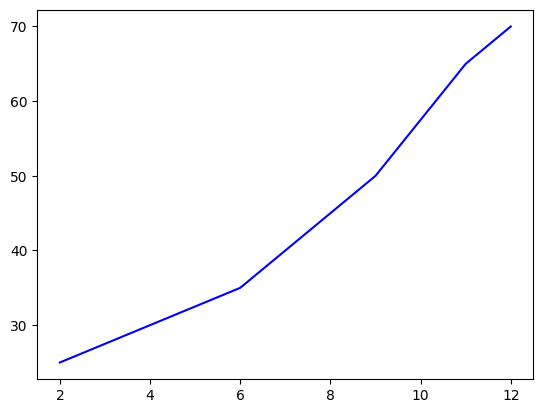

In [361]:
# Indskrivning af datapunkter:

x = np.array([2.0, 6.0, 9.0, 11.0, 12.0])
y = np.array([25.0, 35.0, 50.0, 65.0, 70.0])

fig, ax = plt.subplots()
ax.plot(x, y, color="b")

# b) Bestemmelse af funktion på formen f(x) = a + bx + cx^2, som går igennem de 3 sidste data punkter.

For at gøre dette opstiller jeg en udvidet matrix ud fra den følgende ligning:
[1, x2, x2^2]     [a]     [y2]
[1, x3, x3^2]  *  [b]  =  [y3]  
[1, x4, x4^2]     [c]     [y4]

Hvis jeg nu løser ligningen så matricen ender med at være identitetsmatricen, så kan jeg blot aflæse a, b og c på højre side af lighedstegnet.

In [362]:
# Opskrivning af matricen:
vslut = np.array([9, 11, 12], dtype=float)

matrix1 = np.vander(vslut, 3, increasing=True)

# Opskrivning af søjlevektoren
vektor1 = np.array([50, 65, 70], dtype=float) [:, np.newaxis]

matrix1, vektor1

(array([[  1.,   9.,  81.],
        [  1.,  11., 121.],
        [  1.,  12., 144.]]),
 array([[50.],
        [65.],
        [70.]]))

Jeg har nu opstilt: 

$$Av = b$$

Jeg laver nu en sammensat matrix af $A$ og $b$.

In [363]:
# Jeg laver nu den udvidede matrix
ligsys = np.hstack((matrix1, vektor1))
ligsys

array([[  1.,   9.,  81.,  50.],
       [  1.,  11., 121.,  65.],
       [  1.,  12., 144.,  70.]])

Jeg kan nu begynde at løse ligningssystemet med elementære rækkeoperationer:

In [364]:
ligsys[1] -= ligsys[0]
ligsys 

array([[  1.,   9.,  81.,  50.],
       [  0.,   2.,  40.,  15.],
       [  1.,  12., 144.,  70.]])

In [365]:
ligsys[2] -= ligsys[0]
ligsys

array([[ 1.,  9., 81., 50.],
       [ 0.,  2., 40., 15.],
       [ 0.,  3., 63., 20.]])

In [366]:
ligsys[0] -= 4*ligsys[1]
ligsys

array([[  1.,   1., -79., -10.],
       [  0.,   2.,  40.,  15.],
       [  0.,   3.,  63.,  20.]])

In [367]:
ligsys[2] -= 1.5*ligsys[1]
ligsys

array([[  1. ,   1. , -79. , -10. ],
       [  0. ,   2. ,  40. ,  15. ],
       [  0. ,   0. ,   3. ,  -2.5]])

In [368]:
ligsys[1] = ligsys[1]/2
ligsys

array([[  1. ,   1. , -79. , -10. ],
       [  0. ,   1. ,  20. ,   7.5],
       [  0. ,   0. ,   3. ,  -2.5]])

In [369]:
ligsys[0] -= ligsys[1]
ligsys

array([[  1. ,   0. , -99. , -17.5],
       [  0. ,   1. ,  20. ,   7.5],
       [  0. ,   0. ,   3. ,  -2.5]])

In [370]:
ligsys[2] = 1/3*ligsys[2]
ligsys

array([[  1.        ,   0.        , -99.        , -17.5       ],
       [  0.        ,   1.        ,  20.        ,   7.5       ],
       [  0.        ,   0.        ,   1.        ,  -0.83333333]])

In [371]:
ligsys[1] -= 20*ligsys[2]
ligsys

array([[  1.        ,   0.        , -99.        , -17.5       ],
       [  0.        ,   1.        ,   0.        ,  24.16666667],
       [  0.        ,   0.        ,   1.        ,  -0.83333333]])

In [372]:
ligsys[0] += 99*ligsys[2]
ligsys

array([[   1.        ,    0.        ,    0.        , -100.        ],
       [   0.        ,    1.        ,    0.        ,   24.16666667],
       [   0.        ,    0.        ,    1.        ,   -0.83333333]])

Jeg kan nu i ligningen ovenfor aflæse a, b og c til at være: a = -100, b = 24.1666667 og c = -0,833333

Jeg plotter nu den nye funktion:

Text(10, 55, 'Approximated function')

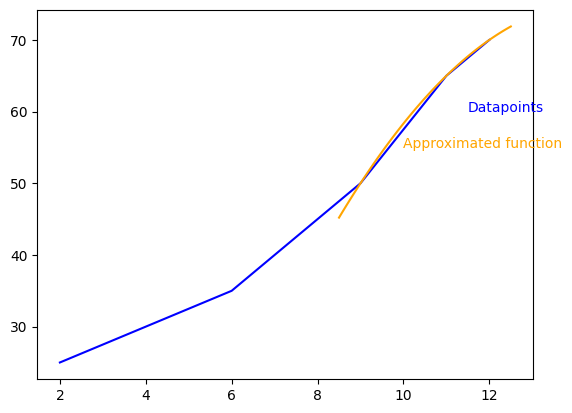

In [373]:
# Opskrivning af variable
a = ligsys[0, 3]
b = ligsys[1, 3]
c = ligsys[2, 3]

# Opskrivning af funktionen
xfunc = np.linspace(8.5, 12.5, 100)
yfunc = c * xfunc**2 + b * xfunc + a

# Jeg kan nu plotte funktionen
fig, ax = plt.subplots()
ax.plot(x, y, color = "b")
ax.plot(xfunc, yfunc, color = "orange")
ax.annotate("Datapoints", (11.5, 60), color = "b")
ax.annotate("Approximated function", (10, 55), color = "orange")

# c) Bestemmelse af det polynomie af mindste grad, som kan modellere de 5 datapunkter, og plot af dette polynomie.

Når vi har 5 punkter, er det mindste grads polynomie vi kan have, et 4. gradspolynomie.

In [374]:
# Fra første delopgave har jeg alle mine datapunkter.
# Opskriver søjlevektoren som skal være med til at danne min udvidede matrix
y [:, np.newaxis]

array([[25.],
       [35.],
       [50.],
       [65.],
       [70.]])

In [375]:
# Jeg opskriver nu matricen som også skal være med til at danne den udvidede matrice
xs = x [:, np.newaxis]
matrix2 = np.vander(x[:], 5, increasing=True)
matrix2

array([[1.0000e+00, 2.0000e+00, 4.0000e+00, 8.0000e+00, 1.6000e+01],
       [1.0000e+00, 6.0000e+00, 3.6000e+01, 2.1600e+02, 1.2960e+03],
       [1.0000e+00, 9.0000e+00, 8.1000e+01, 7.2900e+02, 6.5610e+03],
       [1.0000e+00, 1.1000e+01, 1.2100e+02, 1.3310e+03, 1.4641e+04],
       [1.0000e+00, 1.2000e+01, 1.4400e+02, 1.7280e+03, 2.0736e+04]])

In [376]:
# Jeg laver nu mit ligningssystem ved at stacke vektoren og matricen
ligsys2 = np.hstack((matrix2, y [:, np.newaxis]))
ligsys2

array([[1.0000e+00, 2.0000e+00, 4.0000e+00, 8.0000e+00, 1.6000e+01,
        2.5000e+01],
       [1.0000e+00, 6.0000e+00, 3.6000e+01, 2.1600e+02, 1.2960e+03,
        3.5000e+01],
       [1.0000e+00, 9.0000e+00, 8.1000e+01, 7.2900e+02, 6.5610e+03,
        5.0000e+01],
       [1.0000e+00, 1.1000e+01, 1.2100e+02, 1.3310e+03, 1.4641e+04,
        6.5000e+01],
       [1.0000e+00, 1.2000e+01, 1.4400e+02, 1.7280e+03, 2.0736e+04,
        7.0000e+01]])

In [377]:
# Jeg løser nu ligningssystemet "ligsys2"
løsning2 = np.linalg.solve(matrix2, y [:, np.newaxis])
løsning2

array([[-5.71428571e+00],
       [ 2.55476190e+01],
       [-6.36507937e+00],
       [ 6.82539683e-01],
       [-2.38095238e-02]])

(array([-5.71428571]),
 array([25.54761905]),
 array([-6.36507937]),
 array([0.68253968]),
 array([-0.02380952]))

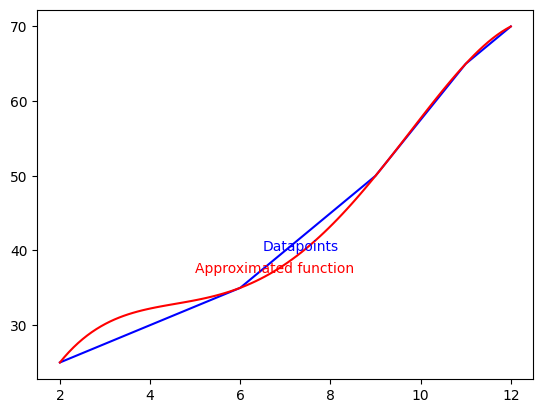

In [399]:
# Jeg kan nu plotte den givne funktion
# Opskrivning af variable
a2 = løsning2[0]
b2 = løsning2[1]
c2 = løsning2[2]
d2 = løsning2[3]
e2 = løsning2[4]

# Opskrivning af funktionen
xfunc = np.linspace(2, 12, 100)
yfunc = e2 * xfunc**4 + d2 * xfunc**3 + c2 * xfunc**2 + b2 * xfunc + a2

# Jeg kan nu plotte funktionen
fig, ax = plt.subplots()
ax.plot(x, y, color = "b")
ax.plot(xfunc, yfunc, color = "red")
ax.annotate("Datapoints", (6.5, 40), color = "b")
ax.annotate("Approximated function", (5, 37), color = "red")

a2, b2, c2, d2, e2

# d) Bestemmelse af en sammensat funktion, bestående af 2 3. gradspolynomier, som efterligner datasættet:

Da der er tale om 3. gradspolynomier, snakker vi om dem på formen: f(x) = a + bx + cx^2 + dx^3.

Jeg får givet informationerne:
1. 1. delfunktion går igennem de første 3 punkter.
2. 2. delfunktion går igennem de sidste 3 punkter.
3. Begge delfunktioner har samme samme hældning når x = 8.0

Jeg kan nu altså opstille 2 ligningssystemer bestående af 4 ligninger og 4 ubekendte hver. Dog kender vi ikke svaret på den sidste ligning, da dette vil være en hældning. Dette vil forårsage en af variablene til at være frie, derfor vil vi have uendeligt mange løsninger.

Dette kan løses ved at give de to sidste ligninger i begge ligningssystemer den samme vilkårlige værdi.



In [379]:
# Opskrivning af dataene
y [:, np.newaxis], x

(array([[25.],
        [35.],
        [50.],
        [65.],
        [70.]]),
 array([ 2.,  6.,  9., 11., 12.]))

In [380]:
# Opstilling af de to matricer som er dele af den udvidede matrice
xdel1 = x[0:3]
delmatrix1 = np.vander(xdel1, 4, increasing=True)

xdel2 = x[2:5]
delmatrix2 = np.vander(xdel2, 4, increasing=True)


delmatrix1, delmatrix2

(array([[  1.,   2.,   4.,   8.],
        [  1.,   6.,  36., 216.],
        [  1.,   9.,  81., 729.]]),
 array([[1.000e+00, 9.000e+00, 8.100e+01, 7.290e+02],
        [1.000e+00, 1.100e+01, 1.210e+02, 1.331e+03],
        [1.000e+00, 1.200e+01, 1.440e+02, 1.728e+03]]))

In [381]:
# Jeg har nu opstilt 2 matricer med 3 ligninger ligesom i de tidligere opgaver. 
# For nu at tilføje d. 4. ligning, er jeg nødt til at differentierer funktionen, indsætte x-koordinaten 8,
# og en vilkårlig hældning

# Den differentierede funktion vil se ud som følger:
# f'(x) = b + 2*cx + 3*dx^2
# Jeg indsætter nu denne række i mine matricer:
diffrække = np.array([0, 1, 2*x[2], 3*x[2]*x[2]], dtype=float)

delmatrix1 = np.vstack((delmatrix1, diffrække))
delmatrix2 = np.vstack((delmatrix2, diffrække))

delmatrix1, delmatrix2

(array([[  1.,   2.,   4.,   8.],
        [  1.,   6.,  36., 216.],
        [  1.,   9.,  81., 729.],
        [  0.,   1.,  18., 243.]]),
 array([[1.000e+00, 9.000e+00, 8.100e+01, 7.290e+02],
        [1.000e+00, 1.100e+01, 1.210e+02, 1.331e+03],
        [1.000e+00, 1.200e+01, 1.440e+02, 1.728e+03],
        [0.000e+00, 1.000e+00, 1.800e+01, 2.430e+02]]))

In [382]:
# Opstilling af de to søjlevektorer med svar på ligninger
ydel1 = y [:, np.newaxis] [0:3]
ydel2 = y [:, np.newaxis] [2:5]

# Jeg har nu opstilt 2 søjle vektorer med svarene på de 3 første ligninger.
# Jeg kan nu tilføje en vilkårlig hældning som svar på den 4. ligning i begge udvidede matricer
hældning = np.array([5])
ydel1 = np.vstack((ydel1, hældning))
ydel2 = np.vstack((ydel2, hældning))

ydel1, ydel2

(array([[25.],
        [35.],
        [50.],
        [ 5.]]),
 array([[50.],
        [65.],
        [70.],
        [ 5.]]))

In [383]:
# Jeg kan nu lave mine udvidede matricer

lignsysdel1 = np.hstack((delmatrix1, ydel1))
lignsysdel2 = np.hstack((delmatrix2, ydel2))

lignsysdel1, lignsysdel2

(array([[  1.,   2.,   4.,   8.,  25.],
        [  1.,   6.,  36., 216.,  35.],
        [  1.,   9.,  81., 729.,  50.],
        [  0.,   1.,  18., 243.,   5.]]),
 array([[1.000e+00, 9.000e+00, 8.100e+01, 7.290e+02, 5.000e+01],
        [1.000e+00, 1.100e+01, 1.210e+02, 1.331e+03, 6.500e+01],
        [1.000e+00, 1.200e+01, 1.440e+02, 1.728e+03, 7.000e+01],
        [0.000e+00, 1.000e+00, 1.800e+01, 2.430e+02, 5.000e+00]]))

Nu hvor jeg har opstilt mine to udvidede matricer kan jeg løse dem ligesom i forrige opgave.

In [384]:
del1løs = np.linalg.solve(delmatrix1, ydel1)
del2løs = np.linalg.solve(delmatrix2, ydel2)

del1løs, del2løs

(array([[29.79591837],
        [-4.64285714],
        [ 1.2244898 ],
        [-0.05102041]]),
 array([[ 7.25000000e+02],
        [-2.11250000e+02],
        [ 2.13888889e+01],
        [-6.94444444e-01]]))

Jeg kan nu opstille to ligninger på 2 forskællige intervaller, og dernæst plotte de to:

Text(5, 37, 'Approximated function')

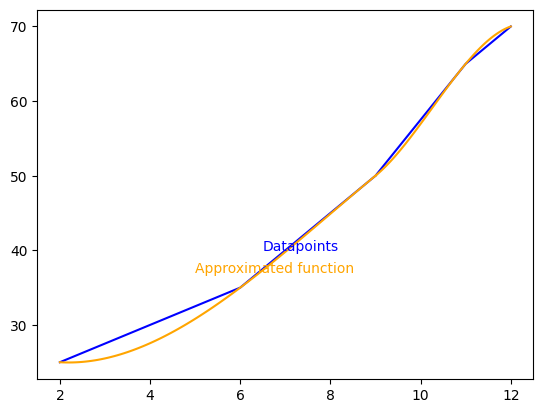

In [385]:
# Opstilling af p1(x)
x1plot = np.linspace(2, 9, 100)
y1plot = del1løs[0] + del1løs[1]*x1plot + del1løs[2]*x1plot**2 + del1løs[3]*x1plot**3

# Opstilling af p2(x)
x2plot = np.linspace(9, 12, 100)
y2plot = del2løs[0] + del2løs[1]*x2plot + del2løs[2]*x2plot**2 + del2løs[3]*x2plot**3

# Jeg kan nu plotte funktionen
fig, ax = plt.subplots()
ax.plot(x, y, color = "b")
ax.plot(x1plot, y1plot, color = "orange")
ax.plot(x2plot, y2plot, color = "orange")
ax.annotate("Datapoints", (6.5, 40), color = "b")
ax.annotate("Approximated function", (5, 37), color = "orange")

# e) Bevis for at ligningssystemet har mere end 1 løsning

$\color{red} \text{lav matricen til echelonform for generelt bevis} \color{black}$

For at gøre dette, udfører jeg blot operationerne igen, blot med en anden fælles hældning i punktet x = 8.0

In [386]:
# Opstilling af de to søjlevektorer
ydel1 = y [:, np.newaxis] [0:3]
ydel2 = y [:, np.newaxis] [2:5]

# Jeg har nu opstilt 2 søjle vektorer med svarene på de 3 første ligninger.
# Jeg kan nu tilføje en vilkårlig hældning som svar på den 4. ligning i begge udvidede matricer
hældning = np.array([-30])         # Nu er hældningen 30 fremfor 5
ydel1 = np.vstack((ydel1, hældning))
ydel2 = np.vstack((ydel2, hældning))

In [387]:
# Jeg kan nu lave mine udvidede matricer

lignsysdel1 = np.hstack((delmatrix1, ydel1))
lignsysdel2 = np.hstack((delmatrix2, ydel2))

lignsysdel1, lignsysdel2

(array([[  1.,   2.,   4.,   8.,  25.],
        [  1.,   6.,  36., 216.,  35.],
        [  1.,   9.,  81., 729.,  50.],
        [  0.,   1.,  18., 243., -30.]]),
 array([[ 1.000e+00,  9.000e+00,  8.100e+01,  7.290e+02,  5.000e+01],
        [ 1.000e+00,  1.100e+01,  1.210e+02,  1.331e+03,  6.500e+01],
        [ 1.000e+00,  1.200e+01,  1.440e+02,  1.728e+03,  7.000e+01],
        [ 0.000e+00,  1.000e+00,  1.800e+01,  2.430e+02, -3.000e+01]]))

In [388]:
del1løs = np.linalg.solve(delmatrix1, ydel1)
del2løs = np.linalg.solve(delmatrix2, ydel2)

del1løs, del2løs

(array([[ 209.79591837],
        [-144.64285714],
        [  29.55782313],
        [  -1.71768707]]),
 array([[ 7.65500000e+03],
        [-2.18875000e+03],
        [ 2.08055556e+02],
        [-6.52777778e+00]]))

Text(5, 37, 'Approximated function')

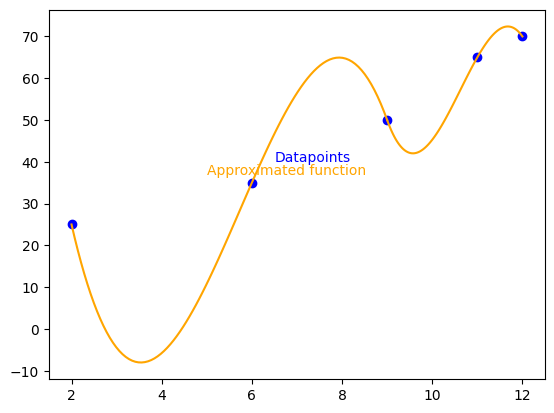

In [389]:
# Opstilling af p1(x)
x1plot = np.linspace(2, 9, 100)
y1plot = del1løs[0] + del1løs[1]*x1plot + del1løs[2]*x1plot**2 + del1løs[3]*x1plot**3

# Opstilling af p2(x)
x2plot = np.linspace(9, 12, 100)
y2plot = del2løs[0] + del2løs[1]*x2plot + del2løs[2]*x2plot**2 + del2løs[3]*x2plot**3

# Jeg kan nu plotte funktionen
fig, ax = plt.subplots()
ax.plot(x, y, 'o', color = "b")
ax.plot(x1plot, y1plot, color = "orange")
ax.plot(x2plot, y2plot, color = "orange")
ax.annotate("Datapoints", (6.5, 40), color = "b")
ax.annotate("Approximated function", (5, 37), color = "orange")

# f) Bestemmelse af en betingelse i den afledte af p1(x), i punktet x = 2, så der kun er en entydig løsning til ligningssystemerne.

Ved at lade værdien af p1'(2) være fx 5, så angiver vi en hældning i punktet 2. Dette giver os 4 ligninger med 4 løsninger i 1. delligningsystem. Dette vil resultere i en fastlåst hældning i x = 8.0 for p1(x). Vi kan nu benytte denne hældning i ligningssystemet p2(x). Nu har vi også her 4 ligninger med 4 løsninger, hvilket igen resultere i et entydigt svar.

Altså kan vi med en vilkårlig værdi for p1'(2), fastlåse begge ligningsystemer og dermed få en entydig løsning.

Metode følger:

In [390]:
# Opskrivning af dataene
y [:, np.newaxis], x

(array([[25.],
        [35.],
        [50.],
        [65.],
        [70.]]),
 array([ 2.,  6.,  9., 11., 12.]))

In [391]:
# Opstilling af de to matricer som er dele af den udvidede matrice
xs = x [:, np.newaxis]
xdel1 = x[0:3]
delmatrix1 = np.vander(xdel1, 4, increasing=True)

xdel2 = x[2:5]
delmatrix2 = np.vander(xdel2, 4, increasing=True)

# Jeg har nu opstilt 2 matricer med 3 ligninger ligesom i de tidligere opgaver. 
# For nu at tilføje d. 4. ligning, er jeg nødt til at differentierer funktionen, indsætte x-koordinaterne 2 og 8,
# Den differentierede funktion vil se ud som følger:
# og en vilkårlig hældning for x = 2
# f'(x) = b + 2*cx + 3*dx^2
# Jeg indsætter nu disse rækker i mine matricer:
diffrække1 = np.array([0, 1, 2*x[0], 3*x[0]*x[0]])
diffrække2 = np.array([0, 1, 2*x[2], 3*x[2]*x[2]])

delmatrix1 = np.vstack((delmatrix1, diffrække1))
delmatrix2 = np.vstack((delmatrix2, diffrække2))

delmatrix1, delmatrix2

(array([[  1.,   2.,   4.,   8.],
        [  1.,   6.,  36., 216.],
        [  1.,   9.,  81., 729.],
        [  0.,   1.,   4.,  12.]]),
 array([[1.000e+00, 9.000e+00, 8.100e+01, 7.290e+02],
        [1.000e+00, 1.100e+01, 1.210e+02, 1.331e+03],
        [1.000e+00, 1.200e+01, 1.440e+02, 1.728e+03],
        [0.000e+00, 1.000e+00, 1.800e+01, 2.430e+02]]))

In [392]:
# Opstilling af de to søjlevektorer
ydel1 = y [:, np.newaxis] [0:3]
ydel2 = y [:, np.newaxis] [2:5]

# Jeg har nu opstilt 2 søjle vektorer med svarene på de 3 første ligninger.
# Jeg kan nu tilføje en vilkårlig hældning som svar på den 4. ligning i 1. delligningssystem
hældning = np.array([1])
ydel1 = np.vstack((ydel1, hældning))

ydel1

array([[25.],
       [35.],
       [50.],
       [ 1.]])

In [393]:
# Jeg kan nu opstille min første udvidede matrice:
lignsysdel1 = np.hstack((delmatrix1, ydel1))
lignsysdel1


array([[  1.,   2.,   4.,   8.,  25.],
       [  1.,   6.,  36., 216.,  35.],
       [  1.,   9.,  81., 729.,  50.],
       [  0.,   1.,   4.,  12.,   1.]])

In [394]:
# Jeg kan nu løse det 1. delligningssystem og bestemme p1(x)
del1løs = np.linalg.solve(delmatrix1, ydel1)

del1løs

array([[ 2.45612245e+01],
       [-5.71428571e-01],
       [ 4.00510204e-01],
       [-2.55102041e-03]])

In [395]:
# Jeg opskriver p1(x), og bestemmer hældningen i punktet x = 8
# f'(x) = b + 2*cx + 3*dx^2
xkoordinat = 9
hældningix9 = del1løs[1]+2*del1løs[2]*xkoordinat+3*del1løs[3]*xkoordinat**2

# Jeg kan nu opstille mit 2. delligningssystem med den nye bestemte hældning
hældning2 = np.array([hældningix9])
ydel2 = np.vstack((ydel2, hældning2))

ydel2

array([[50.        ],
       [65.        ],
       [70.        ],
       [ 6.01785714]])

In [396]:
# Jeg kan nu opstille min udvidede matrice for 2. delligningssystem
lignsysdel2 = np.hstack((delmatrix2, ydel2))
lignsysdel2

array([[1.00000000e+00, 9.00000000e+00, 8.10000000e+01, 7.29000000e+02,
        5.00000000e+01],
       [1.00000000e+00, 1.10000000e+01, 1.21000000e+02, 1.33100000e+03,
        6.50000000e+01],
       [1.00000000e+00, 1.20000000e+01, 1.44000000e+02, 1.72800000e+03,
        7.00000000e+01],
       [0.00000000e+00, 1.00000000e+00, 1.80000000e+01, 2.43000000e+02,
        6.01785714e+00]])

In [397]:
# Jeg kan nu løse mit ligningsystem og bestemme p2(x)
del2løs = np.linalg.solve(delmatrix2, ydel2)
del2løs

array([[ 523.46428571],
       [-153.74107143],
       [  15.96031746],
       [  -0.52480159]])

Text(5, 37, 'Approximated function')

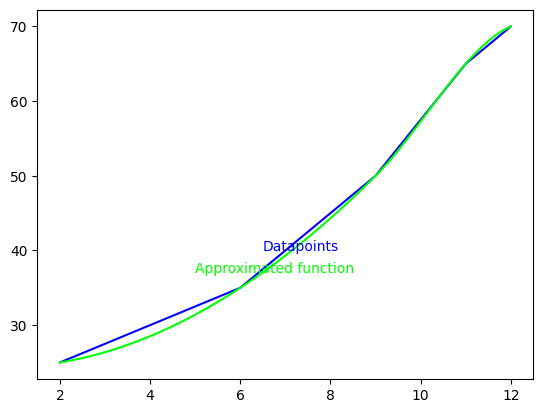

In [398]:
# Jeg kan nu bestemme funktionerne p1(x) og p2(x)
x1plot = np.linspace(2, 9, 100)
y1plot = del1løs[0]+del1løs[1]*x1plot+del1løs[2]*x1plot*x1plot+del1løs[3]*x1plot*x1plot*x1plot

x2plot = np.linspace(9, 12, 100)
y2plot = del2løs[0]+del2løs[1]*x2plot+del2løs[2]*x2plot*x2plot+del2løs[3]*x2plot*x2plot*x2plot

fig, ax = plt.subplots()
ax.plot(x, y, color="b")
ax.plot(x1plot, y1plot, color="lime")
ax.plot(x2plot, y2plot, color="lime")
ax.annotate("Datapoints", (6.5, 40), color = "b")
ax.annotate("Approximated function", (5, 37), color = "lime")

# g) Hvilken model vil jeg helst benytte mig af: (b), (c) eller (f), og hvorfor?

Jeg ville nok anvende metoden fra (f), da det er modellen som udnytter mest data, og dermed nok også er den der modellere forløbet bedst.

Dog ville jeg nok hellere bruge en hældning fra et punkt tættere på y = 55.0, fx i x = 8.0, da dette nok vil give et bedre billede af det omkring liggende forløb.